# 00. Initial Data Discovery and Profiling

## 1. Import Necessary Libraries
Import pandas, numpy, matplotlib, and seaborn for data analysis and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load CSV Files
Define the paths for the .csv files and load them into pandas DataFrames. In this case, I am opting for three separate DataFrames.

In [2]:
# Create a dictionary with the different file paths
rutas = {
    'climbers': '../data/raw/climber_df.csv',
    'grades': '../data/raw/grades_conversion_table.csv',
    'routes': '../data/raw/routes_rated.csv'
}

# Load everything into a dictionary of DataFrames
dfs = {nombre: pd.read_csv(path) for nombre, path in rutas.items()}

## 3. Visualize the First Rows of the Dataset
Display the first rows of the DataFrames using head() to get a general overview of the data.

In [3]:
for name, df in dfs.items():
    print(f"\n{40*'*'}\nDataFrame: '{name}'")
    display(df.head())


****************************************
DataFrame: 'climbers'


,user_id,country,sex,height,weight,age,years_cl,date_first,date_last,grades_count,grades_first,grades_last,grades_max,grades_mean,year_first,year_last
0,1,SWE,0,177,73,41.0,21,1999-02-06 23:00:00,2001-07-31 22:00:00,84,36,55,62,46.750000,1999,2001
1,3,SWE,0,180,78,44.0,22,1999-03-31 22:00:00,2000-07-19 22:00:00,12,53,51,59,52.833333,1999,2000
2,4,SWE,1,165,58,33.0,16,2004-06-30 22:00:00,2009-05-26 22:00:00,119,53,49,64,53.890756,2004,2009
3,10,SWE,0,167,63,52.0,25,2000-01-14 23:00:00,2017-06-01 22:00:00,298,53,49,63,49.406040,2000,2017
4,16,NOR,0,177,68,44.0,21,1998-02-27 23:00:00,2010-05-13 22:00:00,5,53,49,53,51.400000,1998,2010



****************************************
DataFrame: 'grades'


,Unnamed: 0,grade_id,grade_fra
0,0,0,-
1,1,1,-
2,2,2,-
3,3,3,1
4,4,4,1a



****************************************
DataFrame: 'routes'


,Unnamed: 0,name_id,country,crag,sector,name,tall_recommend_sum,grade_mean,cluster,rating_tot
0,0,0,and,montserrat,prohibitivo,diagonal de la x,-1,49.250000,3,-0.045211
1,1,1,and,montserrat,prohibitivo,mehir,-1,49.000000,2,0.116464
2,2,2,and,montserrat,prohibitivo,pas de la discordia,0,49.000000,2,0.178722
3,3,3,and,tartareu,bombo suis,tenedor libre,0,44.333333,3,0.158449
4,4,4,arg,bandurrias,rincon,tendinitis,1,48.500000,0,0.075797


At first glance, in the 'climbers' DataFrame, I notice that the calendar columns 'date_first' and 'date_last' contain combined date and time information; it would be useful to separate them into distinct columns for better visualization later (not used in this initial project). Additionally, there may be certain columns that will not be used.

In the 'grades' and 'routes' DataFrames, there is an index column ('Unnamed: 0') that is redundant. I will remove these during the cleaning phase.

## 4. Explore General Dataset Information
Use info() and shape to display information about the number of rows, columns, and data types.

In [4]:
for name, df in dfs.items():
    print(f"\n{40*'*'}\nDataFrame: '{name}'")
    df.info()
    print(f"Number of rows: {df.shape[0]}")
    print(f"Number of columns: {df.shape[1]}")


****************************************
DataFrame: 'climbers'
<class 'pandas.DataFrame'>
RangeIndex: 10927 entries, 0 to 10926
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       10927 non-null  int64  
 1   country       10927 non-null  str    
 2   sex           10927 non-null  int64  
 3   height        10927 non-null  int64  
 4   weight        10927 non-null  int64  
 5   age           10927 non-null  float64
 6   years_cl      10927 non-null  int64  
 7   date_first    10927 non-null  str    
 8   date_last     10927 non-null  str    
 9   grades_count  10927 non-null  int64  
 10  grades_first  10927 non-null  int64  
 11  grades_last   10927 non-null  int64  
 12  grades_max    10927 non-null  int64  
 13  grades_mean   10927 non-null  float64
 14  year_first    10927 non-null  int64  
 15  year_last     10927 non-null  int64  
dtypes: float64(2), int64(11), str(3)
memory usage: 1.3 MB
Numbe

## 5. Describe Numerical and Categorical Variables
Use describe() for numerical variables and value_counts() for categorical variables.

In [5]:
for name, df in dfs.items():
    print(f"\n{40*'*'}\nDataFrame: '{name}'")
    display(df.describe())
    for col in df.columns:
        # Testing string/object columns for category counts
        if df[col].dtype == 'string' or df[col].dtype == 'object':
            print("Column: ", end="")
            print(df[col].value_counts())
            print(25*"-")
      


****************************************
DataFrame: 'climbers'


,user_id,sex,height,weight,age,years_cl,grades_count,grades_first,grades_last,grades_max,grades_mean,year_first,year_last
count,10927.00000,10927.000000,10927.000000,10927.000000,10927.000000,10927.000000,10927.000000,10927.000000,10927.000000,10927.000000,10927.000000,10927.000000,10927.000000
mean,29411.09774,0.125103,176.152009,67.608676,33.333852,12.672188,79.794546,45.648851,46.983802,53.764437,45.505055,2008.621946,2012.311613
std,18022.12695,0.330851,8.508669,9.677316,7.590989,6.108451,141.411297,9.478173,9.418087,9.679533,7.891356,28.833298,4.161484
min,1.00000,0.000000,137.000000,40.000000,12.000000,1.000000,1.000000,28.000000,28.000000,29.000000,28.500000,0.000000,1991.000000
25%,14651.00000,0.000000,171.000000,63.000000,28.000000,8.000000,8.000000,38.000000,40.000000,46.000000,39.400000,2006.000000,2009.000000
50%,27323.00000,0.000000,177.000000,68.000000,33.000000,12.000000,28.000000,46.000000,48.000000,55.000000,45.151899,2009.000000,2013.000000
75%,43240.50000,0.000000,182.000000,73.000000,38.000000,17.000000,90.000000,53.000000,53.000000,62.000000,51.210084,2012.000000,2016.000000
max,67020.00000,1.000000,202.000000,93.000000,69.000000,29.000000,2445.000000,75.000000,77.000000,77.000000,75.272727,2017.000000,2017.000000


Column: country
ESP      1306
USA      1248
other     984
POL       830
ITA       798
SWE       632
FRA       607
DEU       505
BRA       427
NOR       355
AUT       337
ZAF       323
CAN       306
RUS       266
AUS       244
NLD       233
GBR       228
CHE       225
PRT       185
BEL       176
HRV       163
SVN       148
MEX       146
DNK       119
CZE        78
FIN        58
Name: count, dtype: int64
-------------------------
Column: date_first
2005-12-31 23:00:00    32
2002-08-31 22:00:00    18
2005-04-30 22:00:00    18
2005-06-30 22:00:00    17
2002-04-30 22:00:00    15
                       ..
2017-08-15 22:00:00     1
2017-08-21 22:00:00     1
2017-09-03 22:00:00     1
2017-09-09 22:00:00     1
2017-06-14 22:00:00     1
Name: count, Length: 4443, dtype: int64
-------------------------
Column: date_last
2017-09-09 22:00:00    118
2017-08-26 22:00:00     76
2017-09-08 22:00:00     73
2017-09-02 22:00:00     72
2017-09-01 22:00:00     58
                      ... 
2015-03-26 23:00:

,Unnamed: 0,grade_id
count,85.000000,85.000000
mean,42.000000,42.000000
std,24.681302,24.681302
min,0.000000,0.000000
25%,21.000000,21.000000
50%,42.000000,42.000000
75%,63.000000,63.000000
max,84.000000,84.000000


Column: grade_fra
-          3
1          1
1a         1
1b         1
1c         1
          ..
9b+/9c     1
9c         1
9c/+       1
9c+        1
9c+/10a    1
Name: count, Length: 83, dtype: int64
-------------------------

****************************************
DataFrame: 'routes'


,Unnamed: 0,name_id,tall_recommend_sum,grade_mean,cluster,rating_tot
count,55858.000000,55858.000000,55858.000000,55858.000000,55858.000000,5.585800e+04
mean,27928.500000,27928.500000,0.023041,46.799255,2.210588,1.704550e-17
std,16124.960005,16124.960005,0.965519,9.168034,1.708326,1.404031e-01
min,0.000000,0.000000,-16.000000,29.000000,0.000000,-1.822021e-01
25%,13964.250000,13964.250000,0.000000,39.937500,2.000000,-7.347453e-02
50%,27928.500000,27928.500000,0.000000,46.000000,2.000000,-4.284822e-02
75%,41892.750000,41892.750000,0.000000,53.000000,2.000000,4.529507e-02
max,55857.000000,55857.000000,24.000000,77.333333,8.000000,1.044532e+00


Column: country
esp    15293
ita     6423
usa     4566
fra     4198
pol     4149
deu     2868
aut     2159
grc     2093
bra     1503
nor      963
svn      946
aus      900
che      817
tur      733
hrv      707
zaf      701
can      629
prt      591
rom      567
mex      522
swe      506
bel      486
tha      444
bgr      433
gbr      427
nzl      371
ukr      357
rus      290
arg      171
hun      163
srb      158
ven      115
chn      107
isr       84
lao       65
svk       63
per       41
chl       36
lux       36
mar       28
isl       26
cze       25
dnk       20
vnm       10
mlt        9
fin        8
mkd        7
reu        7
jor        6
msr        6
col        5
and        4
bih        3
nld        3
pri        3
twn        3
ind        2
ecu        1
phl        1
Name: count, dtype: int64
-------------------------
Column: crag
frankenjura       1596
kalymnos          1206
arco              1174
cuenca             814
montserrat         797
                  ... 
restuarant    

I want to determine if 'name_id' is a primary key in the 'routes' DataFrame or if it corresponds to 'user_id' in the 'climbers' DataFrame.

In [6]:
is_pk_routes = dfs['routes']['name_id'].is_unique
print(f"'name_id' is a primary key: {is_pk_routes}")
is_pk_climbers = dfs['climbers']['user_id'].is_unique
print(f"'user_id' is a primary key: {is_pk_climbers}")

'name_id' is a primary key: True
'user_id' is a primary key: True


Based on this, I conclude that 'climbers' and 'routes' are not directly related by these IDs.

## 6. Visualize Null and Duplicate Values
Identify and visualize the count of null values and duplicate rows in the dataset.

In [7]:
for name, df in dfs.items():
    print(f"\n{40*'*'}\nDataFrame: '{name}'")

    # Null values
    print("\nNull values per column:")
    print(df.isnull().sum())

    # Duplicated rows
    print("\nDuplicate rows: ", end="")
    print(df.duplicated().sum())


****************************************
DataFrame: 'climbers'

Null values per column:
user_id         0
country         0
sex             0
height          0
weight          0
age             0
years_cl        0
date_first      0
date_last       0
grades_count    0
grades_first    0
grades_last     0
grades_max      0
grades_mean     0
year_first      0
year_last       0
dtype: int64

Duplicate rows: 0

****************************************
DataFrame: 'grades'

Null values per column:
Unnamed: 0    0
grade_id      0
grade_fra     0
dtype: int64

Duplicate rows: 0

****************************************
DataFrame: 'routes'

Null values per column:
Unnamed: 0            0
name_id               0
country               0
crag                  0
sector                0
name                  0
tall_recommend_sum    0
grade_mean            0
cluster               0
rating_tot            0
dtype: int64

Duplicate rows: 0


As we can see, the DataFrames are currently clean; it would be interesting to introduce some noise later to utilize the cleaning functions.

## 7. Univariate Analysis of Numerical Variables
Create histograms and boxplots to analyze the distribution of numerical variables.


****************************************
DataFrame: 'climbers'


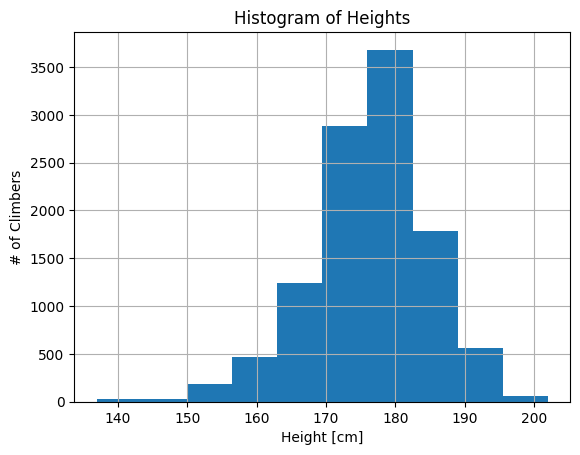

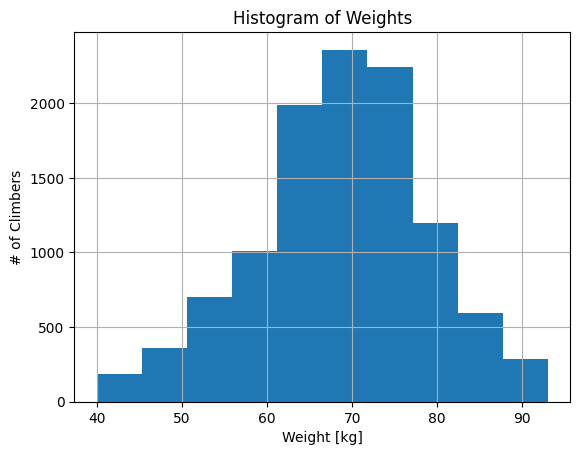

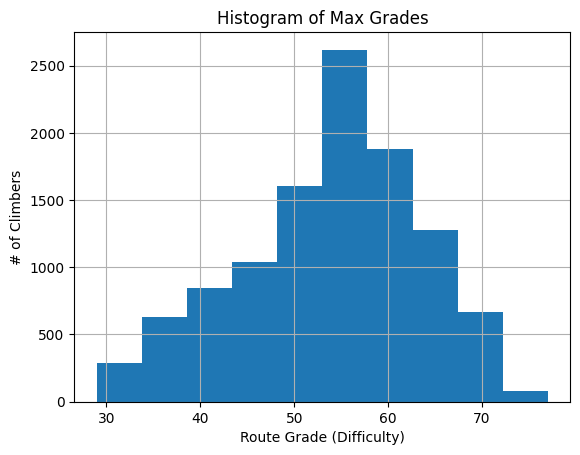

C:\Users\Pablo\AppData\Local\Temp\ipykernel_10784\3359275916.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfs['climbers'], x='sex', y='grades_mean', palette='pastel')


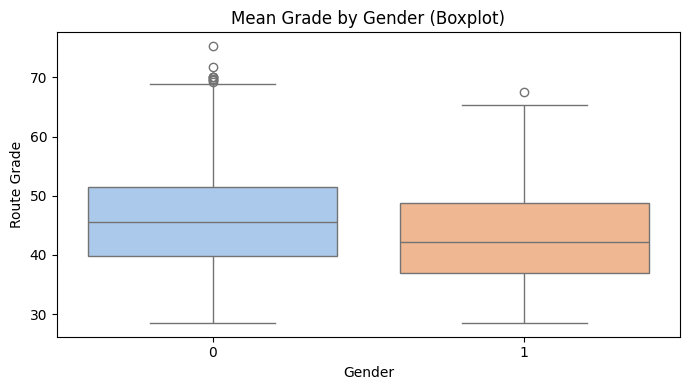

In [8]:
# I will generate histograms for variables that are potentially interesting
print(f"\n{40*'*'}\nDataFrame: 'climbers'")

dfs['climbers']['height'].hist()
plt.title('Histogram of Heights')
plt.ylabel('# of Climbers')
plt.xlabel('Height [cm]')
plt.xticks(rotation = 0)
plt.show()

dfs['climbers']['weight'].hist()
plt.title('Histogram of Weights')
plt.ylabel('# of Climbers')
plt.xlabel('Weight [kg]')
plt.xticks(rotation = 0)
plt.show()

dfs['climbers']['grades_max'].hist()
plt.title('Histogram of Max Grades')
plt.ylabel('# of Climbers')
plt.xlabel('Route Grade (Difficulty)')
plt.xticks(rotation = 0)
plt.show()

plt.figure(figsize=(7,4))
sns.boxplot(data=dfs['climbers'], x='sex', y='grades_mean', palette='pastel')
plt.title('Mean Grade by Gender (Boxplot)')
plt.ylabel('Route Grade')
plt.xlabel('Gender')
plt.tight_layout()
plt.show()


In gender 0 (male), there are several cases of individuals whose levels are significantly above the mean (outliers). Other than that, there does not seem to be a major difference in performance levels between genders.

## 8. Univariate Analysis of Categorical Variables
Create bar charts to analyze the frequency of categorical variables.


****************************************
DataFrame: 'climbers'


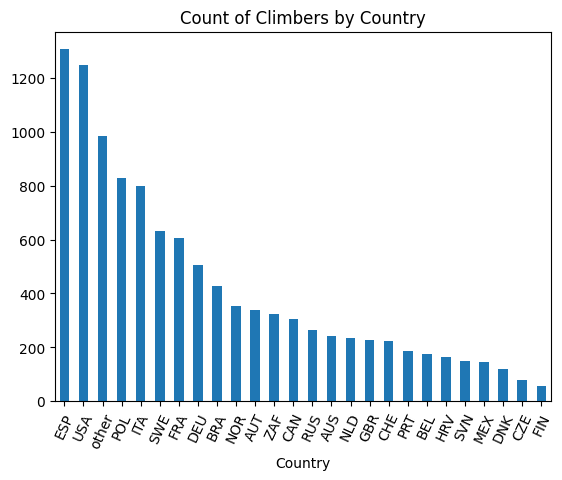


****************************************
DataFrame: 'routes'


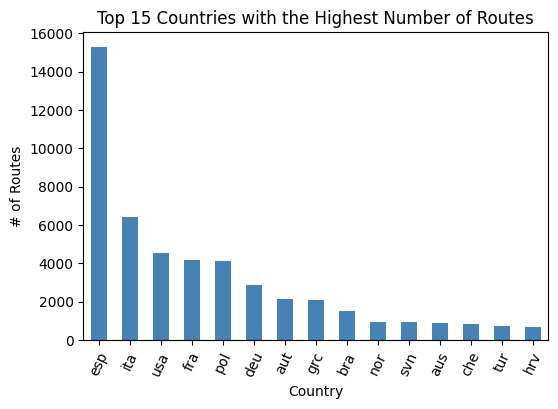

In [9]:
print(f"\n{40*'*'}\nDataFrame: 'climbers'")

dfs['climbers']['country'].value_counts().plot(kind='bar')
plt.title('Count of Climbers by Country')
plt.xlabel('Country')
plt.xticks(rotation = 65)
plt.show()

print(f"\n{40*'*'}\nDataFrame: 'routes'")

# Since there are many countries, I will filter for the top 15
names_top_15 = dfs['routes']['country'].value_counts().head(15).index
df_top_15 = dfs['routes'][dfs['routes']['country'].isin(names_top_15)]
result = df_top_15.groupby('country').size().sort_values(ascending=False)

result.plot(kind = 'bar', figsize=(6,4), color = 'steelblue')
plt.title('Top 15 Countries with the Highest Number of Routes')
plt.xlabel('Country')
plt.ylabel('# of Routes')
plt.xticks(rotation = 65)
plt.show()


## 9. Bivariate Analysis Between Variables
Explore relationships between numerical and categorical variables using scatterplots and cross-tabulations.


****************************************
DataFrame: 'climbers'


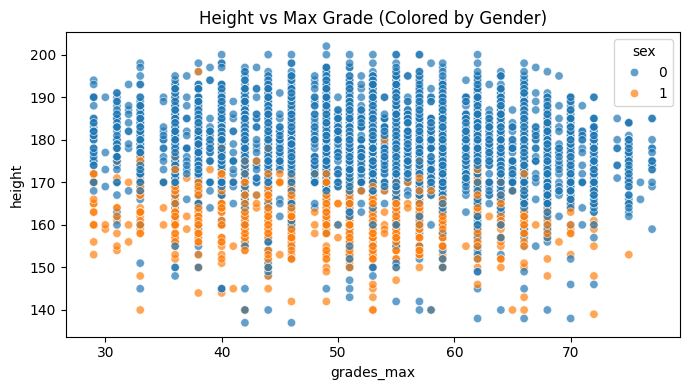

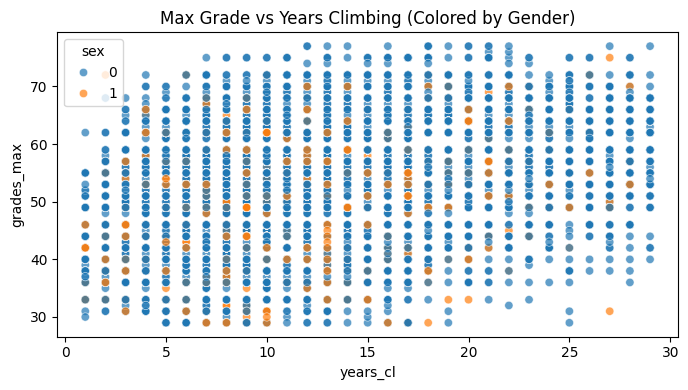

In [10]:
print(f"\n{40*'*'}\nDataFrame: 'climbers'")

plt.figure(figsize=(7,4))
sns.scatterplot(data=dfs['climbers'], x='grades_max', y='height', hue='sex', alpha=0.7)
plt.title('Height vs Max Grade (Colored by Gender)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
sns.scatterplot(data=dfs['climbers'], x='years_cl', y='grades_max', hue='sex', alpha=0.7)
plt.title('Max Grade vs Years Climbing (Colored by Gender)')
plt.tight_layout()
plt.show()


On one hand, it appears that height does not significantly influence the grade level.

On the other hand, I initially assumed that 'years_cl' represented the total climbing years for each individual, but seeing the plot and the records for 'year_first' and 'year_last', it is not entirely clear.

There are 247 records where the final year is less than the initial year.


,user_id,country,sex,height,weight,age,years_cl,date_first,date_last,grades_count,grades_first,grades_last,grades_max,grades_mean,year_first,year_last
21,98,FRA,0,183,78,42.0,24,2000-09-29 22:00:00,1999-07-25 22:00:00,8,38,53,53,45.375000,2000,1999
22,111,SWE,0,187,78,44.0,20,2000-04-30 22:00:00,1998-07-14 22:00:00,8,36,36,38,35.375000,2000,1998
205,1185,FRA,0,170,63,39.0,24,2001-08-10 22:00:00,2000-07-25 22:00:00,160,62,59,68,58.900000,2001,2000
208,1210,FRA,0,164,48,38.0,20,2003-02-19 23:00:00,2002-10-31 23:00:00,2,66,64,66,65.000000,2003,2002
215,1255,BEL,0,178,63,37.0,22,2000-07-10 22:00:00,1997-10-31 23:00:00,12,59,49,59,52.166667,2000,1997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10876,66417,USA,1,155,53,38.0,6,2016-12-01 23:00:00,2015-11-07 23:00:00,35,53,49,53,44.285714,2016,2015
10896,66656,other,1,169,53,24.0,4,2017-07-14 22:00:00,2016-04-23 22:00:00,15,51,33,53,44.066667,2017,2016
10907,66762,POL,0,178,78,35.0,19,2017-07-10 22:00:00,2001-07-18 22:00:00,51,42,38,53,39.078431,2017,2001
10915,66875,ESP,1,160,43,25.0,1,2017-08-02 22:00:00,2016-07-31 22:00:00,10,29,42,42,36.500000,2017,2016


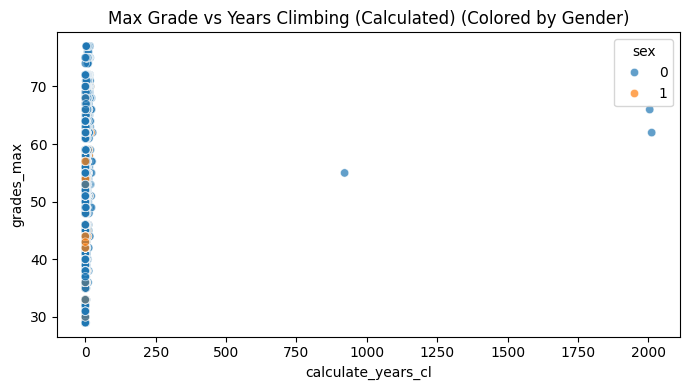

In [11]:
df_climber = dfs['climbers'].copy()

# Check for records where the end year is less than the start year
error = df_climber[df_climber['year_last'] < df_climber['year_first']]
print(f"There are {len(error)} records where the final year is less than the initial year.")
display(error) # This shows the problematic rows

# Overwrite the dataframe only with rows that follow a logical chronological order
df_climber = df_climber[df_climber['year_last'] >= df_climber['year_first']]

# Now we can calculate the column without errors
df_climber['calculate_years_cl'] = df_climber['year_last'] - df_climber['year_first']

plt.figure(figsize=(7,4))
sns.scatterplot(data=df_climber, x='calculate_years_cl', y='grades_max', hue='sex', alpha=0.7)
plt.title('Max Grade vs Years Climbing (Calculated) (Colored by Gender)')
plt.tight_layout()
plt.show()


An upward trend can now be observed here. It is possible that climbers with fewer years of experience simply have not recorded previous years.

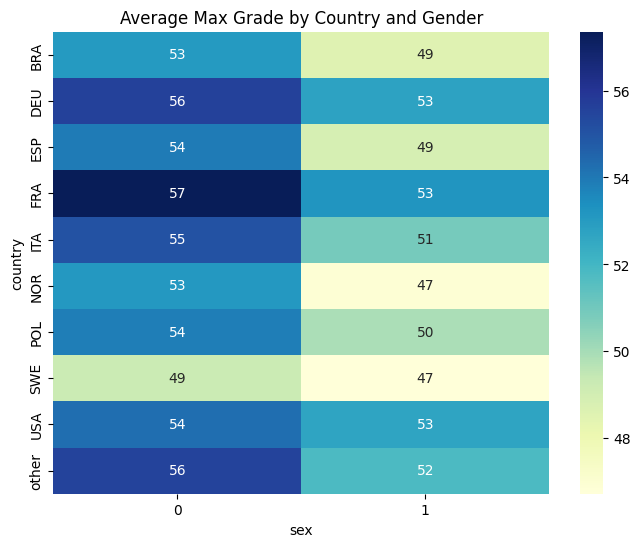

In [12]:
# 1. Get the 10 countries with the most people
top_countries = df_climber['country'].value_counts().head(10).index

# 2. Create a pivot table
pivot_data = df_climber[df_climber['country'].isin(top_countries)].pivot_table(
    index='country', 
    columns='sex', 
    values='grades_max', 
    aggfunc='mean'
)

# 3. Plot
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_data, annot=True, cmap='YlGnBu')
plt.title('Average Max Grade by Country and Gender')
plt.show()

To also work with the 'grades' DataFrame, a merge can be used to create a table showing the top 20 climbers and their grade in the international system.

In [13]:
df_combined = pd.merge(
    dfs['climbers'],
    dfs['grades'],
    left_on='grades_max',
    right_on='grade_id'
)

# Sort by highest grade and then by lowest age
df_sorted = df_combined.sort_values(
    by=['grades_max', 'age'],
    ascending=[False, True]
).reset_index(drop=True)

# Change age to integer
df_sorted['age'] = df_sorted['age'].astype(int)

print("Top 20 Climbers:")
display(df_sorted[['user_id','age','country','grade_fra']].head(20))

Top 20 Climbers:


,user_id,age,country,grade_fra
0,18008,21,POL,9b
1,43983,21,NOR,9b
2,27591,23,SVN,9b
3,1476,24,CZE,9b
4,22437,24,ITA,9b
5,64723,24,FRA,9b
6,30100,28,other,9b
7,2603,30,USA,9b
8,4422,30,USA,9b
9,452,31,USA,9b


## 10. Visualization of Correlations
Calculate and visualize the correlation matrix between numerical variables using a heatmap.

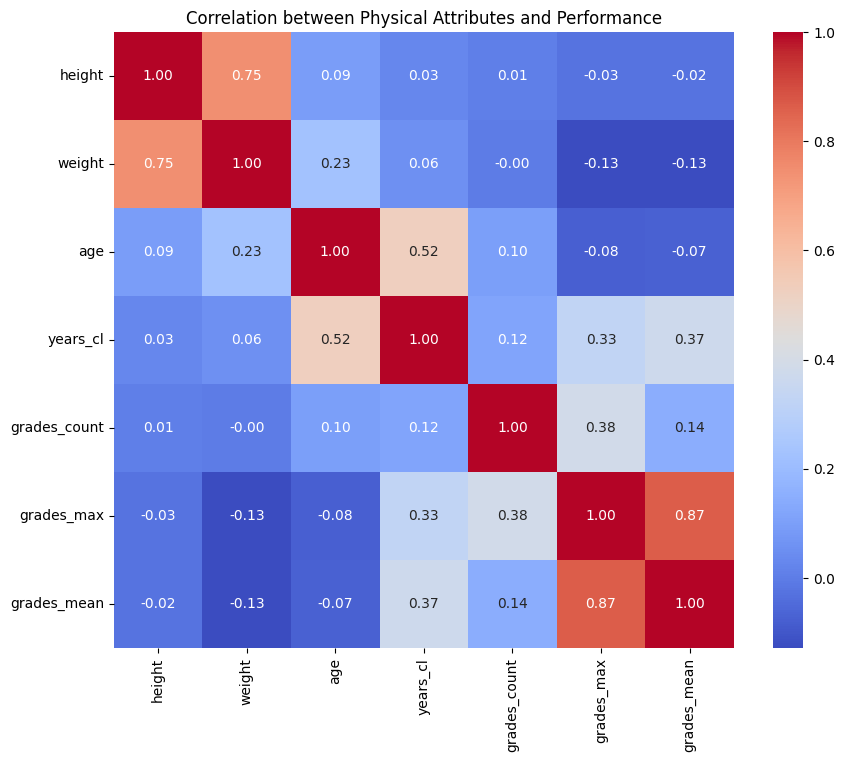

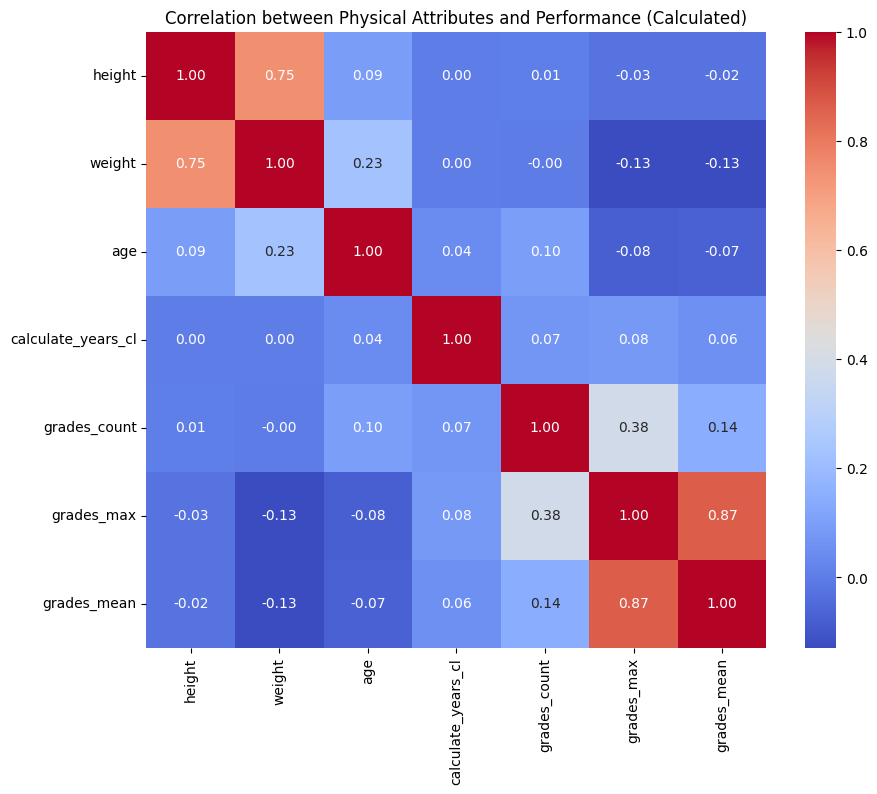

In [14]:
# Select only the numerical columns we are interested in
columns_interest = ['height', 'weight', 'age', 'years_cl', 'grades_count', 'grades_max', 'grades_mean']
corr = df_climber[columns_interest].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation between Physical Attributes and Performance')
plt.show()

columns_interest_calc = ['height', 'weight', 'age', 'calculate_years_cl', 'grades_count', 'grades_max', 'grades_mean']
corr_cal = df_climber[columns_interest_calc].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_cal, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation between Physical Attributes and Performance (Calculated)')
plt.show()


With these two heatmaps, the assumption that 'years_cl' might not equal the total years climbing is supported, as it makes sense to state that years climbing correlate with your max level.
However, it loses the strong correlation between years climbing and age...